# AI-READI Dataset - Comprehensive Exploratory Data Analysis

This notebook provides a comprehensive EDA workflow for the AI-READI dataset stored in Azure Blob Storage.

## Dataset Overview
- **Storage**: Azure Blob Storage (staireadi01/aireadi-raw)
- **Total Size**: ~97.54 GB
- **Total Files**: 24,256 blobs
- **Project**: AI-READI (Artificial Intelligence Ready and Equitable Atlas for Diabetes Insights)

## Data Modalities
1. **Clinical Data** (OMOP CDM) - CSV files
2. **ECG Data** (WFDB format) - .dat/.hea files
3. **Environmental Sensor Data** - CSV files
4. **Wearable Activity Data** - JSON files
5. **Blood Glucose Data** - JSON files

## Setup

In [1]:
import sys
import os

# Add parent directory to path
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Azure imports
from azure.storage.blob import BlobServiceClient
from config.azure_config import CONNECTION_STRING, CONTAINER_NAME

# WFDB for ECG data
import wfdb

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


## 1. Container Overview

Load and review the blob storage scan results.

In [2]:
# Load scan results
scan_dir = '../results/scans'
scan_files = sorted([f for f in os.listdir(scan_dir) if f.startswith('blob_scan_')])
latest_scan = scan_files[-1]

with open(f'{scan_dir}/{latest_scan}', 'r') as f:
    scan_data = json.load(f)

print(f"Scan timestamp: {scan_data['scan_timestamp']}")
print(f"Total blobs: {scan_data['total_blobs']:,}")
print(f"Total size: {scan_data['total_size_gb']:.2f} GB")
print(f"Unique file types: {len(scan_data['file_types'])}")

Scan timestamp: 2026-01-23T14:34:27.157357
Total blobs: 24,256
Total size: 97.54 GB
Unique file types: 8


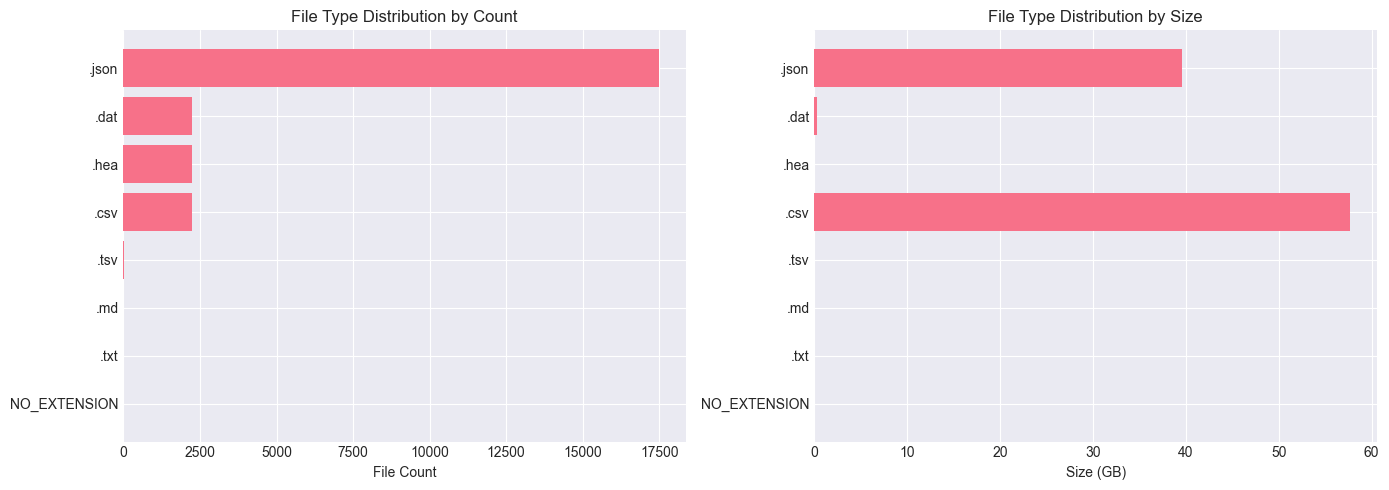

,extension,count,size_gb
6,.json,17494,3.956549e+01
2,.dat,2257,2.774633e-01
3,.hea,2257,4.157761e-03
5,.csv,2237,5.769141e+01
4,.tsv,6,6.014542e-03
0,.md,3,6.950554e-05
1,.txt,1,1.279544e-05
7,NO_EXTENSION,1,1.862645e-08


In [3]:
# Visualize file type distribution
file_types = scan_data['file_types']
file_type_df = pd.DataFrame([
    {'extension': ext, 'count': data['count'], 'size_gb': data['total_size'] / (1024**3)}
    for ext, data in file_types.items()
]).sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].barh(file_type_df['extension'], file_type_df['count'])
axes[0].set_xlabel('File Count')
axes[0].set_title('File Type Distribution by Count')
axes[0].invert_yaxis()

# Size plot
axes[1].barh(file_type_df['extension'], file_type_df['size_gb'])
axes[1].set_xlabel('Size (GB)')
axes[1].set_title('File Type Distribution by Size')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

file_type_df

## 2. Metadata Exploration

Examine dataset description and structure.

In [4]:
# Load dataset description
with open('../results/scans/dataset_description.json', 'r') as f:
    dataset_desc = json.load(f)

print("Dataset Description:")
for key, value in dataset_desc.items():
    if isinstance(value, (str, int, float)):
        print(f"  {key}: {value}")
    else:
        print(f"  {key}: <{type(value).__name__}>")

Dataset Description:
  schema: https://schema.aireadi.org/v0.1.0/dataset_description.json
  identifier: <dict>
  title: <list>
  version: 3.0.0
  creator: <list>
  publicationYear: 2025
  date: <list>
  resourceType: <dict>
  datasetDeIdentLevel: <dict>
  datasetConsent: <dict>
  description: <list>
  language: en
  relatedIdentifier: <list>
  subject: <list>
  managingOrganization: <dict>
  accessType: PublicDownloadSelfAttestationRequired
  accessDetails: <dict>
  rights: <list>
  publisher: <dict>
  size: <list>
  fundingReference: <list>
  format: <list>


## 3. Clinical Data Analysis (OMOP CDM)

Analyze clinical data samples.

In [5]:
# Load person table sample
person_df = pd.read_csv('../data/samples/person_sample.csv')

print(f"Person Table Shape: {person_df.shape}")
print(f"\nColumns: {list(person_df.columns)}")
person_df.head()

Person Table Shape: (100, 18)

Columns: ['person_id', 'gender_concept_id', 'year_of_birth', 'month_of_birth', 'day_of_birth', 'birth_datetime', 'race_concept_id', 'ethnicity_concept_id', 'location_id', 'provider_id', 'care_site_id', 'person_source_value', 'gender_source_value', 'gender_source_concept_id', 'race_source_value', 'race_source_concept_id', 'ethnicity_source_value', 'ethnicity_source_concept_id']


,person_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime,race_concept_id,ethnicity_concept_id,location_id,provider_id,care_site_id,person_source_value,gender_source_value,gender_source_concept_id,race_source_value,race_source_concept_id,ethnicity_source_value,ethnicity_source_concept_id
0,7117,0,1948,0,0,1970-01-01 00:00:00,0,0,0,0,0,,,0,,0,,0
1,7029,0,1967,0,0,1970-01-01 00:00:00,0,0,0,0,0,,,0,,0,,0
2,7072,0,1980,0,0,1970-01-01 00:00:00,0,0,0,0,0,,,0,,0,,0
3,7096,0,1958,0,0,1970-01-01 00:00:00,0,0,0,0,0,,,0,,0,,0
4,7064,0,1956,0,0,1970-01-01 00:00:00,0,0,0,0,0,,,0,,0,,0


In [6]:
# Load observation table sample
observation_df = pd.read_csv('../data/samples/observation_sample.csv')

print(f"Observation Table Shape: {observation_df.shape}")
print(f"\nColumns: {list(observation_df.columns)}")
observation_df.head()

Observation Table Shape: (1000, 22)

Columns: ['Unnamed: 0', 'observation_id', 'person_id', 'observation_concept_id', 'observation_date', 'observation_datetime', 'observation_type_concept_id', 'value_as_number', 'value_as_string', 'value_as_concept_id', 'qualifier_concept_id', 'unit_concept_id', 'provider_id', 'visit_occurrence_id', 'visit_detail_id', 'observation_source_value', 'observation_source_concept_id', 'unit_source_value', 'qualifier_source_value', 'value_source_value', 'observation_event_id', 'obs_event_field_concept_id']


,Unnamed: 0,observation_id,person_id,observation_concept_id,observation_date,observation_datetime,observation_type_concept_id,value_as_number,value_as_string,value_as_concept_id,...,provider_id,visit_occurrence_id,visit_detail_id,observation_source_value,observation_source_concept_id,unit_source_value,qualifier_source_value,value_source_value,observation_event_id,obs_event_field_concept_id
0,1,3,7117,2005200289,2023-12-12,2023-12-12 00:00:00,32862,1.0,1.0,45877994,...,0,2,0,"rtop_odd, OptoMed-Disc centered-CFP",0,NaN,Right eye,,0,0
1,2,4,7117,2005200290,2023-12-12,2023-12-12 00:00:00,32862,1.0,1.0,45877994,...,0,2,0,"rtop_odm, OptoMed-Mac centered-CFP",0,NaN,Right eye,,0,0
2,3,5,7117,2005200291,2023-12-12,2023-12-12 00:00:00,32862,1.0,1.0,45877994,...,0,2,0,"rtei_odir, Eidon-UWF Central-IR",0,NaN,Right eye,,0,0
3,4,6,7117,2005200292,2023-12-12,2023-12-12 00:00:00,32862,1.0,1.0,45877994,...,0,2,0,"rtei_odfaf, Eidon-UWF Central-FAF",0,NaN,Right eye,,0,0
4,5,7,7117,2005200293,2023-12-12,2023-12-12 00:00:00,32862,1.0,1.0,45877994,...,0,2,0,"rtsm_odc, Eidon-UWF Central-CFP",0,NaN,Right eye,,0,0


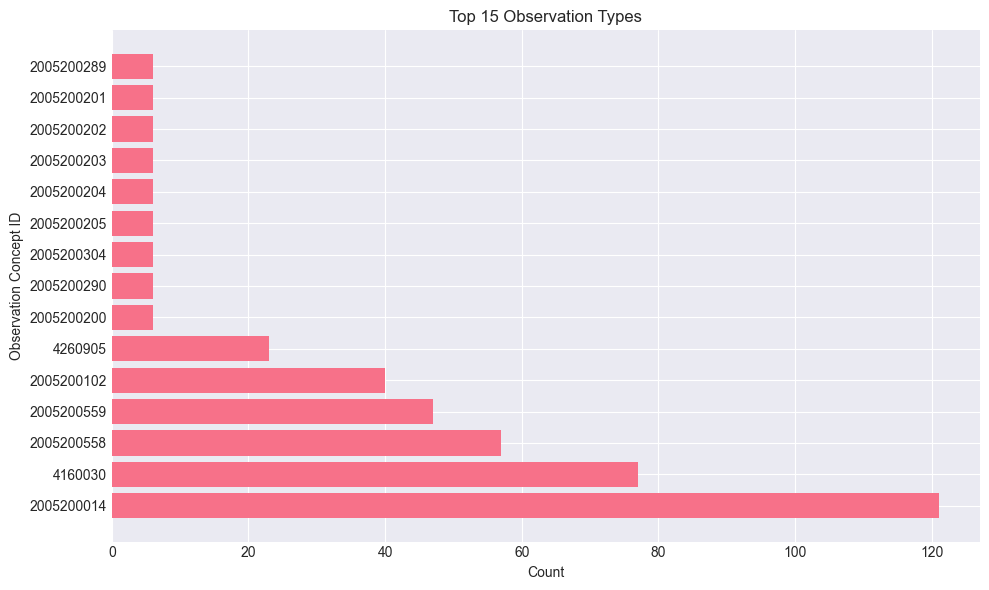

In [7]:
# Analyze observation patterns
if 'observation_concept_id' in observation_df.columns:
    top_concepts = observation_df['observation_concept_id'].value_counts().head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_concepts)), top_concepts.values)
    plt.yticks(range(len(top_concepts)), top_concepts.index)
    plt.xlabel('Count')
    plt.ylabel('Observation Concept ID')
    plt.title('Top 15 Observation Types')
    plt.tight_layout()
    plt.show()

## 4. ECG Data Analysis

Examine ECG waveform data characteristics.

In [8]:
# Load ECG sample summary
ecg_summary = pd.read_csv('../results/scans/ecg_sample_summary.csv')

print(f"ECG Recordings Analyzed: {len(ecg_summary)}")
print(f"\nSampling Rate: {ecg_summary['fs'].unique()[0]} Hz")
print(f"Number of Leads: {ecg_summary['n_sig'].unique()[0]}")
print(f"Duration: {ecg_summary['duration_sec'].mean():.1f} seconds (average)")

ecg_summary.head()

ECG Recordings Analyzed: 10

Sampling Rate: 500 Hz
Number of Leads: 12
Duration: 11.0 seconds (average)


,record_name,n_sig,sig_name,fs,sig_len,duration_sec,units,comments,base_date,base_time
0,1258_ecg_6a95cb4d,12,"['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', ...",500,5500,11.0,"['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV...","['manufacturer: Philips', 'device_model: PageW...",NaN,NaN
1,7754_ecg_6f87ebf7,12,"['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', ...",500,5500,11.0,"['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV...","['manufacturer: Philips', 'device_model: PageW...",NaN,NaN
2,4412_ecg_51bec670,12,"['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', ...",500,5500,11.0,"['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV...","['manufacturer: Philips', 'device_model: PageW...",NaN,NaN
3,7404_ecg_2bd10705,12,"['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', ...",500,5500,11.0,"['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV...","['manufacturer: Philips', 'device_model: PageW...",NaN,NaN
4,4081_ecg_7d1ea7bf,12,"['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', ...",500,5500,11.0,"['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV...","['manufacturer: Philips', 'device_model: PageW...",NaN,NaN


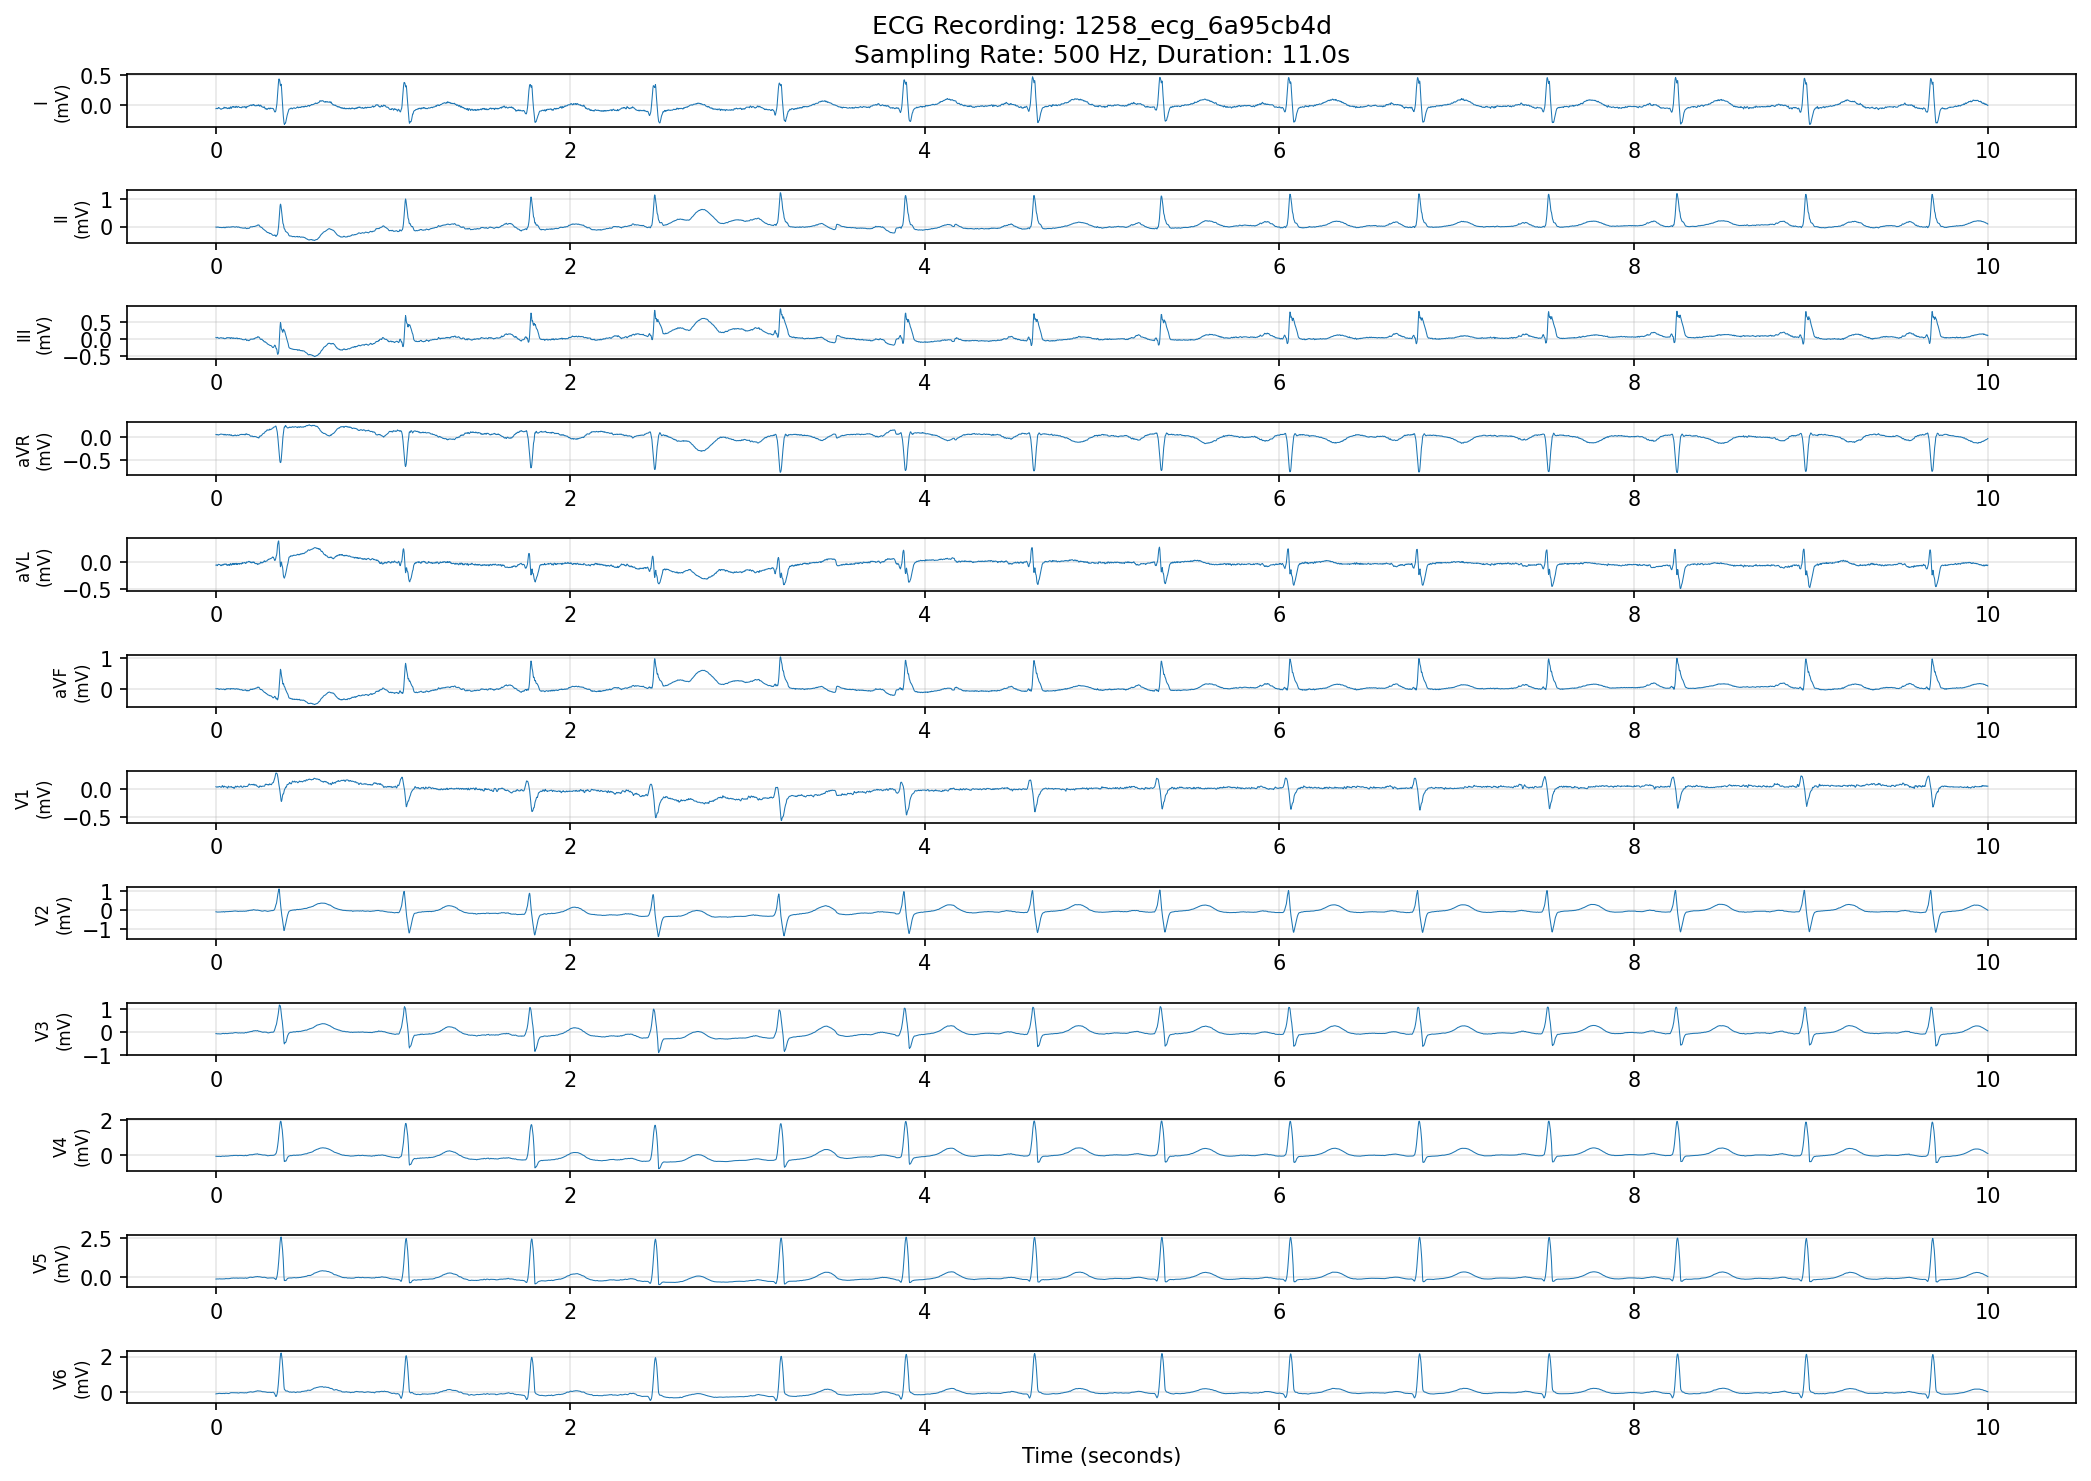

In [9]:
# Display sample ECG visualization
from IPython.display import Image

Image('../results/visualizations/sample_ecg_visualization.png', width=800)

## 5. Data Quality Assessment

Review data quality metrics.

In [10]:
# Check for missing values in clinical data
print("Missing Value Analysis - Person Table:")
missing_pct = (person_df.isnull().sum() / len(person_df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

missing_df[missing_df['Missing %'] > 0]

Missing Value Analysis - Person Table:


,Column,Missing %


## 6. Next Steps and Recommendations

### Recommended Analysis Workflows:

1. **Deep Dive into Clinical Data**
   - Temporal analysis of measurements/observations
   - Patient cohort characterization
   - Comorbidity patterns

2. **ECG Signal Processing**
   - QRS detection and heart rate analysis
   - Arrhythmia detection
   - Signal quality assessment

3. **Environmental Data Integration**
   - Time-series analysis of sensor data
   - Correlation with clinical outcomes

4. **Multi-Modal Integration**
   - Link patient IDs across modalities
   - Temporal alignment of different data types
   - Comprehensive patient profiles

### Useful Functions

All exploration scripts are available in the `scripts/` directory:
- `blob_storage_scanner.py` - Scan blob storage
- `analyze_structure.py` - Analyze directory structure
- `explore_metadata.py` - Explore dataset metadata
- `explore_clinical_data.py` - Analyze clinical data
- `sample_wfdb_data.py` - Sample and visualize ECG data

In [11]:
# Helper function to download specific blobs
def download_blob(blob_name, local_path):
    """Download a specific blob from Azure storage."""
    blob_service_client = BlobServiceClient.from_connection_string(CONNECTION_STRING)
    container_client = blob_service_client.get_container_client(CONTAINER_NAME)
    blob_client = container_client.get_blob_client(blob_name)
    
    with open(local_path, 'wb') as f:
        f.write(blob_client.download_blob().readall())
    
    print(f"✓ Downloaded: {blob_name} -> {local_path}")

# Example usage:
# download_blob(
#     '00b62456-0b93-4975-a992-42ba6a50ed5c/dataset/clinical_data/person.csv',
#     '../data/samples/person_full.csv'
# )